# Detection comparison: classical, latest v10 CenterNet, latest v10 StemCenterNet

Three detection views overlaid on the same VIS tile:

1. **Classical VIS** -- native-resolution peak finder on the Euclid VIS image.
   Fast, robust, and the bootstrap source list everything else is compared to.
2. **Latest V10 CenterNet uncertain+synth round 2** -- bottleneck-path neural detector trained on
   the v10 warm-start foundation features, with uncertain-proposal ignore masks and
   synthetic source augmentation in the recent self-training run.
3. **Latest V10 StemCenterNet uncertain+synth round 2** -- native-resolution stem-path
   detector on the same v10 foundation. It operates on BandStem features before
   bottleneck downsampling, preserving more local spatial detail, and was rerun with
   the same uncertain-proposal / synthetic-source training fixes.

The bright/extended-rescue cell further down is now a diagnostic coverage check:
it asks whether the latest neural detectors already cover obvious large VIS
components, rather than documenting the active checkpoint's training labels.

Both neural detectors share the same v10 foundation. The difference is the
source-evidence path: CenterNet uses the fused bottleneck, while StemCenterNet uses
native-resolution stem features with the same CenterNet-style heatmap heads.

**Fair operating points.** Fixing both detectors at the same `conf_threshold`
isn't apples-to-apples -- their score distributions differ. The threshold-sweep
cell below picks the best-F1 threshold for each detector independently (against
the dedup classical reference) and uses those for the scatter plot and injection
diagnostics, so each detector is shown at its own best operating point.

The classical detector is **not treated as ground truth**. The point is to see
all three on the same tile, where the neural detectors agree, where they
disagree, and where they go beyond classical -- particularly for faint sources
that are only visible after the foundation model fuses the multi-band info.

Foundation: `models/checkpoints/jaisp_v10_warmstart/checkpoint_best.pt`


In [1]:
import sys
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import torch


def find_repo_root(start: Optional[Path] = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for cand in [start, *start.parents]:
        if (cand / 'models').exists() and (cand / 'data').exists():
            return cand
    raise FileNotFoundError('Could not find repo root containing models/ and data/.')


REPO = find_repo_root()
MODELS = REPO / 'models'
for path in [MODELS, MODELS / 'detection', MODELS / 'astrometry2']:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from load_foundation import load_foundation
from detection.centernet_detector import CenterNetDetector
from detection.detector import JAISPEncoderWrapper
from detection.stem_centernet_detector import StemCenterNetDetector
from detection.dataset import _pseudo_labels_vis, _vis_bright_core_and_spike_mask

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Repo root: {REPO}')
print(f'Device: {DEVICE}')


def safe_rms_from_var(var: np.ndarray) -> np.ndarray:
    var = np.asarray(var, dtype=np.float32)
    good = np.isfinite(var) & (var > 0) & (var < 1e20)
    fallback = float(np.sqrt(np.median(var[good]))) if good.any() else 1.0
    out = np.full(var.shape, fallback, dtype=np.float32)
    out[good] = np.sqrt(var[good])
    return out


def to_tensor_1chw(arr: np.ndarray, device: torch.device) -> torch.Tensor:
    arr = np.asarray(arr, dtype=np.float32)
    return torch.from_numpy(arr[None, None]).to(device)


def pick_random_tile_name(rubin_dir: Path, euclid_dir: Path, seed: Optional[int] = None) -> str:
    rubin_stems = sorted(p.stem for p in rubin_dir.glob('tile_x*_y*.npz'))
    shared = [stem for stem in rubin_stems if (euclid_dir / f'{stem}_euclid.npz').exists()]
    if not shared:
        raise RuntimeError('No shared Rubin/Euclid tiles found in the selected directories.')
    rng = np.random.default_rng(seed)
    return str(rng.choice(shared))


def vis_centroids_to_xy(centroids_norm: np.ndarray, hw: tuple[int, int]) -> np.ndarray:
    h, w = hw
    if len(centroids_norm) == 0:
        return np.zeros((0, 2), dtype=np.float32)
    return np.stack([
        centroids_norm[:, 0] * max(w - 1, 1),
        centroids_norm[:, 1] * max(h - 1, 1),
    ], axis=1).astype(np.float32)


def stretch_image(img: np.ndarray, lo: float = 1.0, hi: float = 99.5) -> np.ndarray:
    img = np.asarray(img, dtype=np.float32)
    finite = np.isfinite(img)
    if not finite.any():
        return np.zeros_like(img, dtype=np.float32)
    vals = img[finite]
    vmin, vmax = np.percentile(vals, [lo, hi])
    if vmax <= vmin:
        vmax = vmin + 1e-6
    return np.clip((np.nan_to_num(img, nan=vmin) - vmin) / (vmax - vmin), 0.0, 1.0)


def load_centernet_detector(foundation_ckpt: Path, detector_ckpt: Path, device: torch.device) -> CenterNetDetector:
    foundation = load_foundation(str(foundation_ckpt), device=device, freeze=True)
    encoder = JAISPEncoderWrapper(foundation, freeze=True).to(device)
    detector = CenterNetDetector.load(str(detector_ckpt), encoder=encoder, device=device)
    return detector.eval()


def load_stem_centernet_detector(foundation_ckpt: Path, detector_ckpt: Path, device: torch.device) -> StemCenterNetDetector:
    foundation = load_foundation(str(foundation_ckpt), device=device, freeze=True)
    detector = StemCenterNetDetector.load(str(detector_ckpt), foundation, device=device)
    return detector.eval()


def load_tile_pair(stem: str, rubin_dir: Path, euclid_dir: Path, device: torch.device) -> dict:
    rubin_path = rubin_dir / f'{stem}.npz'
    euclid_path = euclid_dir / f'{stem}_euclid.npz'
    if not rubin_path.exists():
        raise FileNotFoundError(rubin_path)
    if not euclid_path.exists():
        raise FileNotFoundError(euclid_path)

    r = np.load(rubin_path, allow_pickle=True)
    e = np.load(euclid_path, allow_pickle=True)

    rubin_img = np.nan_to_num(np.asarray(r['img'], dtype=np.float32), nan=0.0)
    rubin_var = np.asarray(r['var'], dtype=np.float32)
    rubin_rms = np.stack([safe_rms_from_var(v) for v in rubin_var], axis=0)

    vis_img = np.nan_to_num(np.asarray(e['img_VIS'], dtype=np.float32), nan=0.0)
    vis_hw = tuple(vis_img.shape)

    images = {
        'rubin_u': to_tensor_1chw(rubin_img[0], device),
        'rubin_g': to_tensor_1chw(rubin_img[1], device),
        'rubin_r': to_tensor_1chw(rubin_img[2], device),
        'rubin_i': to_tensor_1chw(rubin_img[3], device),
        'rubin_z': to_tensor_1chw(rubin_img[4], device),
        'rubin_y': to_tensor_1chw(rubin_img[5], device),
        'euclid_VIS': to_tensor_1chw(np.nan_to_num(np.asarray(e['img_VIS'], dtype=np.float32), nan=0.0), device),
        'euclid_Y': to_tensor_1chw(np.nan_to_num(np.asarray(e['img_Y'], dtype=np.float32), nan=0.0), device),
        'euclid_J': to_tensor_1chw(np.nan_to_num(np.asarray(e['img_J'], dtype=np.float32), nan=0.0), device),
        'euclid_H': to_tensor_1chw(np.nan_to_num(np.asarray(e['img_H'], dtype=np.float32), nan=0.0), device),
    }
    rms = {
        'rubin_u': to_tensor_1chw(rubin_rms[0], device),
        'rubin_g': to_tensor_1chw(rubin_rms[1], device),
        'rubin_r': to_tensor_1chw(rubin_rms[2], device),
        'rubin_i': to_tensor_1chw(rubin_rms[3], device),
        'rubin_z': to_tensor_1chw(rubin_rms[4], device),
        'rubin_y': to_tensor_1chw(rubin_rms[5], device),
        'euclid_VIS': to_tensor_1chw(safe_rms_from_var(e['var_VIS']), device),
        'euclid_Y': to_tensor_1chw(safe_rms_from_var(e['var_Y']), device),
        'euclid_J': to_tensor_1chw(safe_rms_from_var(e['var_J']), device),
        'euclid_H': to_tensor_1chw(safe_rms_from_var(e['var_H']), device),
    }

    return {
        'stem': stem,
        'rubin_path': rubin_path,
        'euclid_path': euclid_path,
        'vis_img': vis_img,
        'vis_hw': vis_hw,
        'images': images,
        'rms': rms,
    }


def make_spike_veto_mask(vis_img: np.ndarray, radius: int = 40, width: float = 3.0) -> np.ndarray:
    _, _, mask = _vis_bright_core_and_spike_mask(
        np.asarray(vis_img, dtype=np.float32),
        spike_radius=radius,
        spike_width=width,
        include_core=False,
    )
    return mask


def run_detector(
    detector,
    images: dict,
    rms: dict,
    tile_hw: tuple[int, int],
    conf_threshold: float,
    artifact_mask: Optional[np.ndarray] = None,
) -> tuple[np.ndarray, np.ndarray]:
    with torch.no_grad():
        pred = detector.predict(
            images,
            rms,
            conf_threshold=conf_threshold,
            tile_hw=tile_hw,
            artifact_mask=artifact_mask,
        )
    xy = pred['positions_px'].detach().cpu().numpy().astype(np.float32)
    scores = pred['scores'].detach().cpu().numpy().astype(np.float32)
    return xy, scores


Repo root: /home/shemmati/Work/Projects/JAISP
Device: cuda


In [2]:
RUBIN_DIR = REPO / 'data' / 'rubin_tiles_200'
EUCLID_DIR = REPO / 'data' / 'euclid_tiles_200'

FOUNDATION_CKPT = MODELS / 'checkpoints' / 'jaisp_v10_warmstart' / 'checkpoint_best.pt'
CENTERNET_ROUND2_CKPT = REPO / 'checkpoints' / 'centernet_v10_uncertain_synth_r2' / 'centernet_best.pt'
STEM_CENTERNET_CKPT = REPO / 'checkpoints' / 'stem_centernet_v10_uncertain_synth_r2' / 'stem_centernet_best.pt'

RANDOM_TILE_SEED = None
CLASSICAL_VIS_NSIG = 3.0
# Initial conf thresholds. Overridden later by the threshold-sweep cell, which
# picks the best-F1 threshold for each detector independently.
CENTERNET_CONF_THRESHOLD = 0.30
STEM_CENTERNET_CONF_THRESHOLD = 0.55
SPIKE_VETO_RADIUS = 0
SPIKE_VETO_WIDTH = 0

assert RUBIN_DIR.exists(), RUBIN_DIR
assert EUCLID_DIR.exists(), EUCLID_DIR
assert FOUNDATION_CKPT.exists(), FOUNDATION_CKPT
assert CENTERNET_ROUND2_CKPT.exists(), CENTERNET_ROUND2_CKPT
assert STEM_CENTERNET_CKPT.exists(), STEM_CENTERNET_CKPT

TILE_NAME = pick_random_tile_name(RUBIN_DIR, EUCLID_DIR, seed=RANDOM_TILE_SEED)
print(f'V10 foundation : {FOUNDATION_CKPT}')
print(f'CenterNet r2   : {CENTERNET_ROUND2_CKPT}')
print(f'StemCenterNet  : {STEM_CENTERNET_CKPT}')
print(f'Random tile    : {TILE_NAME}')


V10 foundation : /home/shemmati/Work/Projects/JAISP/models/checkpoints/jaisp_v10_warmstart/checkpoint_best.pt
CenterNet r2   : /home/shemmati/Work/Projects/JAISP/checkpoints/centernet_v10_uncertain_synth_r2/centernet_best.pt
StemCenterNet  : /home/shemmati/Work/Projects/JAISP/checkpoints/stem_centernet_v10_uncertain_synth_r2/stem_centernet_best.pt
Random tile    : tile_x02048_y01792_tract5063_patch_24


In [3]:
# Load the tile and compute the classical pseudo-labels first. Detectors are
# loaded in the cell below — keep them separate so the multi-band-labels
# preview can run before any neural-detector work.

tile = load_tile_pair(TILE_NAME, RUBIN_DIR, EUCLID_DIR, DEVICE)
spike_veto_mask = make_spike_veto_mask(tile['vis_img'], SPIKE_VETO_RADIUS, SPIKE_VETO_WIDTH)

vis_centroids_norm, _, _, _ = _pseudo_labels_vis(tile['vis_img'], nsig=CLASSICAL_VIS_NSIG, max_sources=1000)
vis_classical_xy = vis_centroids_to_xy(vis_centroids_norm, tile['vis_hw'])

print(tile['euclid_path'].name)
print(f'VIS classical detections: {len(vis_classical_xy)}')


tile_x02048_y01792_tract5063_patch_24_euclid.npz
VIS classical detections: 391


## VIS SEP-assist ablation

This is the direct 1:1 check: current `_pseudo_labels_vis` versus the same VIS pipeline with only the internal SEP proposal pass disabled. Bright-core recovery, spike masking, dedupe, and resolved-component cleanup stay the same on both sides.


VIS label ablation on current tile
  tile: tile_x02048_y01792_tract5063_patch_24
  match radius: 5.0 px
  no SEP assist:         286
  current with SEP:      391
  added by SEP assist:   105
  no-SEP only:             0
  net change:           +105


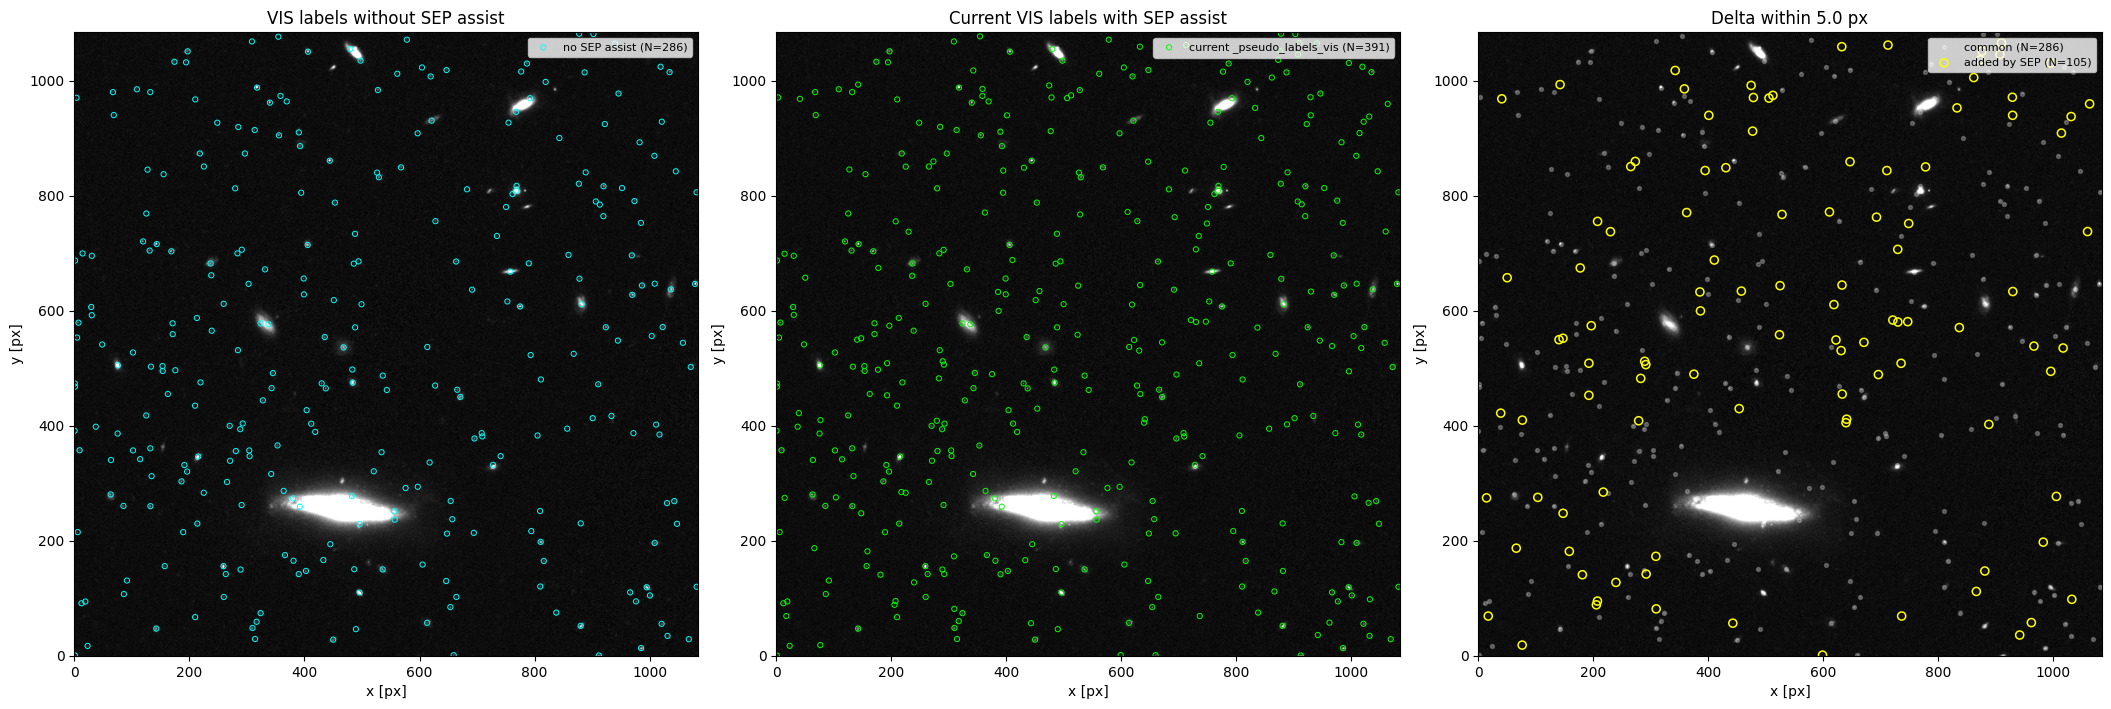

In [4]:
# Compare current _pseudo_labels_vis against the same pipeline with the SEP
# proposal assist disabled. This isolates the effect of _sep_vis_proposals.

from scipy.spatial import cKDTree as _SepAssistTree
import detection.dataset as _det_dataset

SEP_ASSIST_MATCH_RADIUS_PX = 5.0


def _pseudo_labels_vis_no_sep_assist(vis_img: np.ndarray, nsig: float, max_sources: int):
    original_sep = _det_dataset._sep_vis_proposals
    try:
        _det_dataset._sep_vis_proposals = lambda *args, **kwargs: (
            np.zeros(0, dtype=np.float32),
            np.zeros(0, dtype=np.float32),
        )
        return _det_dataset._pseudo_labels_vis(vis_img, nsig=nsig, max_sources=max_sources)
    finally:
        _det_dataset._sep_vis_proposals = original_sep


def _nearest_within(xy: np.ndarray, ref_xy: np.ndarray, radius_px: float) -> tuple[np.ndarray, np.ndarray]:
    if len(xy) == 0:
        return np.zeros(0, dtype=bool), np.zeros(0, dtype=np.float32)
    if len(ref_xy) == 0:
        return np.zeros(len(xy), dtype=bool), np.full(len(xy), np.inf, dtype=np.float32)
    tree = _SepAssistTree(ref_xy)
    dist, _ = tree.query(xy, k=1)
    dist = np.asarray(dist, dtype=np.float32)
    return dist <= float(radius_px), dist


no_sep_norm, _, _, _ = _pseudo_labels_vis_no_sep_assist(
    tile['vis_img'],
    nsig=CLASSICAL_VIS_NSIG,
    max_sources=1000,
)
no_sep_xy = vis_centroids_to_xy(no_sep_norm, tile['vis_hw'])
with_sep_xy = vis_classical_xy

with_has_no, with_to_no = _nearest_within(
    with_sep_xy,
    no_sep_xy,
    SEP_ASSIST_MATCH_RADIUS_PX,
)
no_has_with, no_to_with = _nearest_within(
    no_sep_xy,
    with_sep_xy,
    SEP_ASSIST_MATCH_RADIUS_PX,
)

sep_added_xy = with_sep_xy[~with_has_no]
no_sep_only_xy = no_sep_xy[~no_has_with]
common_with_xy = with_sep_xy[with_has_no]

print('VIS label ablation on current tile')
print(f'  tile: {tile["stem"]}')
print(f'  match radius: {SEP_ASSIST_MATCH_RADIUS_PX:.1f} px')
print(f'  no SEP assist:       {len(no_sep_xy):5d}')
print(f'  current with SEP:    {len(with_sep_xy):5d}')
print(f'  added by SEP assist: {len(sep_added_xy):5d}')
print(f'  no-SEP only:         {len(no_sep_only_xy):5d}')
print(f'  net change:          {len(with_sep_xy) - len(no_sep_xy):+5d}')

fig, axes = plt.subplots(1, 3, figsize=(21, 7), constrained_layout=True)
_img = stretch_image(tile['vis_img'])
H_vis, W_vis = tile['vis_hw']

for ax in axes:
    ax.imshow(_img, cmap='gray', origin='lower')
    ax.set_xlim(0, W_vis)
    ax.set_ylim(0, H_vis)
    ax.set_xlabel('x [px]')
    ax.set_ylabel('y [px]')

if len(no_sep_xy):
    axes[0].scatter(
        no_sep_xy[:, 0], no_sep_xy[:, 1],
        s=14, facecolors='none', edgecolors='cyan', linewidths=0.7,
        label=f'no SEP assist (N={len(no_sep_xy)})',
    )
axes[0].set_title('VIS labels without SEP assist')
axes[0].legend(loc='upper right', fontsize=8)

if len(with_sep_xy):
    axes[1].scatter(
        with_sep_xy[:, 0], with_sep_xy[:, 1],
        s=14, facecolors='none', edgecolors='lime', linewidths=0.7,
        label=f'current _pseudo_labels_vis (N={len(with_sep_xy)})',
    )
axes[1].set_title('Current VIS labels with SEP assist')
axes[1].legend(loc='upper right', fontsize=8)

if len(common_with_xy):
    axes[2].scatter(
        common_with_xy[:, 0], common_with_xy[:, 1],
        s=8, c='white', alpha=0.25, label=f'common (N={len(common_with_xy)})',
    )
if len(sep_added_xy):
    axes[2].scatter(
        sep_added_xy[:, 0], sep_added_xy[:, 1],
        s=34, marker='o', facecolors='none', edgecolors='yellow', linewidths=1.1,
        label=f'added by SEP (N={len(sep_added_xy)})',
    )
if len(no_sep_only_xy):
    axes[2].scatter(
        no_sep_only_xy[:, 0], no_sep_only_xy[:, 1],
        s=36, marker='x', c='red', linewidths=1.1,
        label=f'no-SEP only (N={len(no_sep_only_xy)})',
    )
axes[2].set_title(f'Delta within {SEP_ASSIST_MATCH_RADIUS_PX:.1f} px')
axes[2].legend(loc='upper right', fontsize=8)
plt.show()


## Preview: optional multi-band sep-based labels on the same tile

These are candidate labels for a future CenterNet/StemCenterNet retrain, generated by
[`labels_multiband.py`](../models/detection/labels_multiband.py):
sep (Source Extractor) on VIS, sep on a NIR Y+J+H chi²-stack, cross-matched
into one set of positives with four categories:

- `vis`         — detected in VIS only
- `both`        — detected in VIS *and* NIR (multi-band agreement)
- `nir`         — NIR-only (no VIS counterpart) — the foundation model must use NIR streams to detect these
- `nir_deblend` — extra NIR peaks inside a VIS segment that has ≥2 NIR peaks — cross-band deblending, the cleanest multi-band-only signal

No retraining is happening here. The point is to confirm that the new labels
**look right** on tiles you've already inspected with the existing detectors,
before using the multi-band label source in a later retrain.


Multi-band label diagnostics for this tile:
               n_vis_raw = 533
  n_vis_bright_core_added = 1
               n_nir_raw = 128
        n_vis_post_spike = 523
        n_nir_post_spike = 118
              n_nir_only = 2
           n_nir_deblend = 0
   n_vis_extended_rescue = 8
                 n_total = 533
                  n_both = 114
        n_vis_only_final = 417
        n_nir_only_final = 2
         n_deblend_final = 0
  classical (old)        = 391


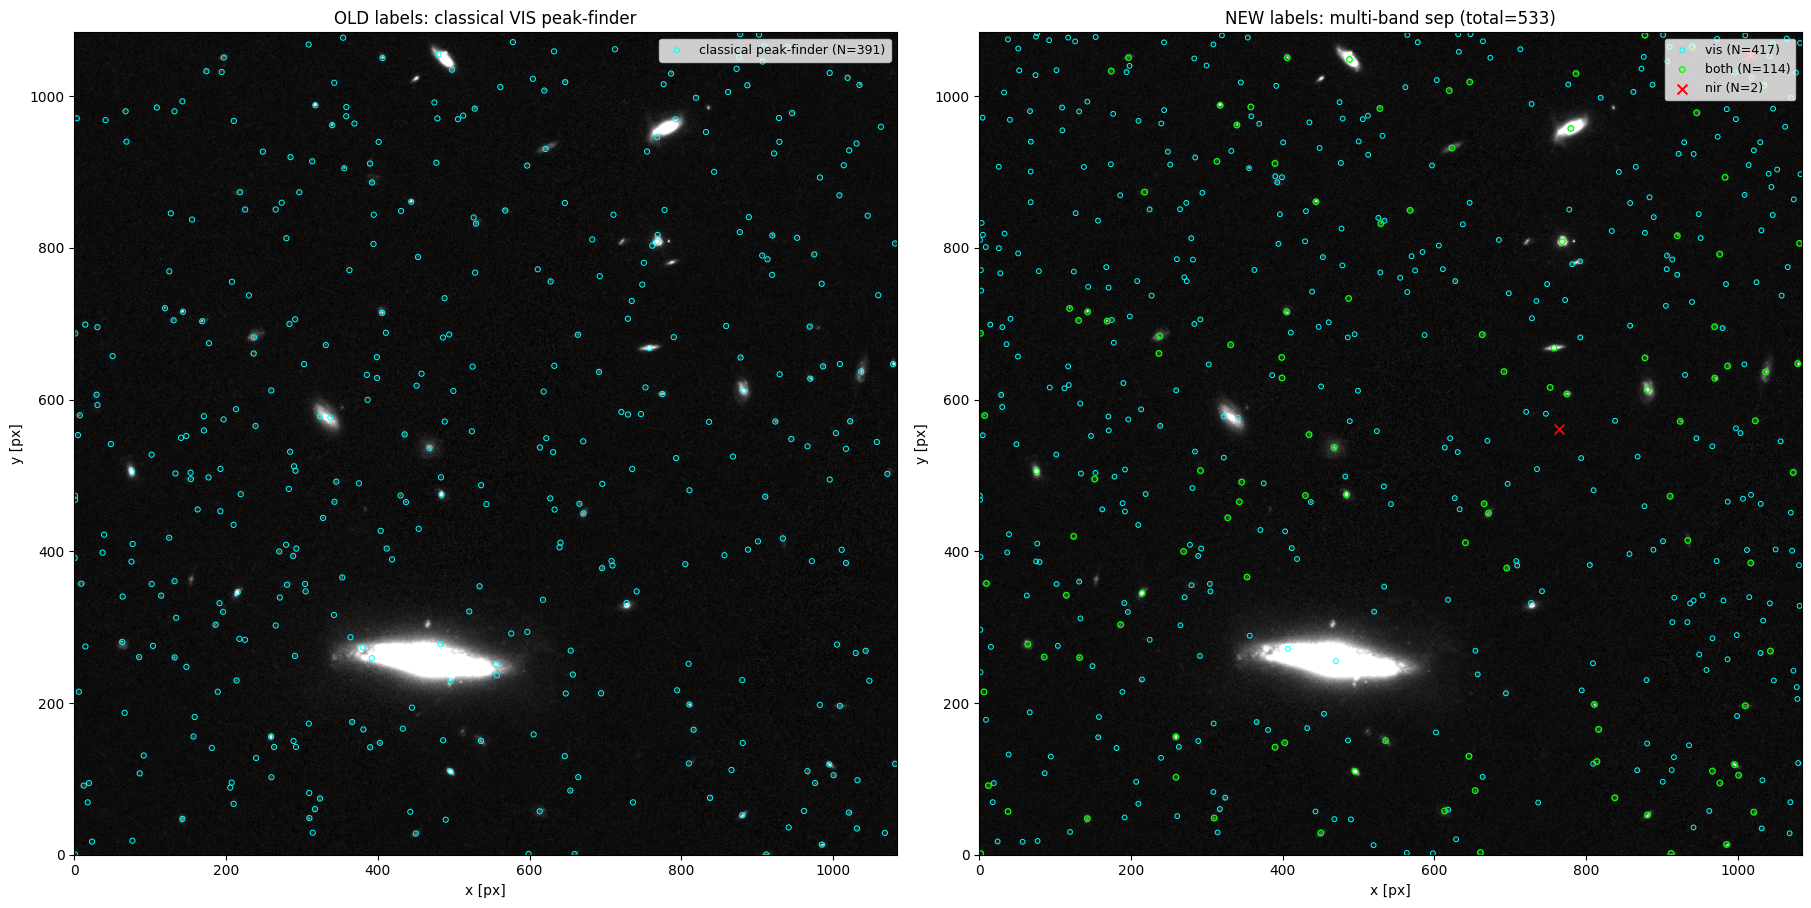

In [5]:
# Preview multi-band sep-based labels on the current tile.
# Tweak the SEP_KWARGS below to iterate -- the cell is cheap to re-run.
# No model retraining happens here.

SEP_KWARGS = dict(
    vis_thresh=1.2,           # sigma above sky for VIS sep.extract
    nir_thresh=1.2,           # sigma above sky for NIR chi2-stack
    minarea=3,                # min connected pixels (3 catches compact faint)
    deblend_nthresh=32,
    deblend_cont=0.005,       # smaller = more aggressive deblending
    cross_match_px=3.0,       # VIS-NIR match radius for 'both' classification
    cross_deblend_min_px=4.0, # NIR peak must be this far from VIS centroid
                              # to count as cross-band deblend
    dedup_px=1.0,
)

if str(MODELS / 'detection') not in sys.path:
    sys.path.insert(0, str(MODELS / 'detection'))
import importlib
import labels_multiband as _lmb
importlib.reload(_lmb)
from labels_multiband import make_multiband_labels

_e = np.load(tile['euclid_path'], allow_pickle=True)
def _g(k):
    return np.nan_to_num(np.asarray(_e[k], dtype=np.float32), nan=0.0)

mb_labels, mb_info = make_multiband_labels(
    _g('img_VIS'), np.asarray(_e['var_VIS'], dtype=np.float32),
    _g('img_Y'),   np.asarray(_e['var_Y'],   dtype=np.float32),
    _g('img_J'),   np.asarray(_e['var_J'],   dtype=np.float32),
    _g('img_H'),   np.asarray(_e['var_H'],   dtype=np.float32),
    **SEP_KWARGS,
)

H_vis, W_vis = tile['vis_hw']
mb_xy = np.stack([
    mb_labels.x_norm * (W_vis - 1),
    mb_labels.y_norm * (H_vis - 1),
], axis=1).astype(np.float32)

print('Multi-band label diagnostics for this tile:')
for _k, _v in mb_info.items():
    print(f'  {_k:>22s} = {_v}')
print(f'  classical (old)        = {len(vis_classical_xy)}')

# Side-by-side: old single-band peak-finder vs new multi-band sep labels.
fig, axes = plt.subplots(1, 2, figsize=(18, 9), constrained_layout=True)
_img = stretch_image(tile['vis_img'])
for ax in axes:
    ax.imshow(_img, cmap='gray', origin='lower')
    ax.set_xlim(0, W_vis)
    ax.set_ylim(0, H_vis)
    ax.set_xlabel('x [px]')
    ax.set_ylabel('y [px]')

if len(vis_classical_xy):
    axes[0].scatter(
        vis_classical_xy[:, 0], vis_classical_xy[:, 1],
        s=14, facecolors='none', edgecolors='cyan', linewidths=0.7,
        label=f'classical peak-finder (N={len(vis_classical_xy)})',
    )
axes[0].set_title('OLD labels: classical VIS peak-finder')
axes[0].legend(loc='upper right', fontsize=9)

cat_styles = {
    'vis':         dict(marker='o', s=12, facecolors='none', edgecolors='cyan',    linewidths=0.7),
    'both':        dict(marker='o', s=16, facecolors='none', edgecolors='lime',    linewidths=1.0),
    'nir':         dict(marker='x', s=50, c='red',                                  linewidths=1.4),
    'nir_deblend': dict(marker='+', s=60, c='magenta',                              linewidths=1.6),
}
for cat, st in cat_styles.items():
    mask = mb_labels.sources == cat
    n = int(mask.sum())
    if n == 0:
        continue
    axes[1].scatter(mb_xy[mask, 0], mb_xy[mask, 1], label=f'{cat} (N={n})', **st)
axes[1].set_title(f'NEW labels: multi-band sep (total={mb_info["n_total"]})')
axes[1].legend(loc='upper right', fontsize=9)
plt.show()


In [6]:
# Load detectors and run them at the initial thresholds above. The
# threshold-sweep cell below picks a fair operating point per detector and
# recomputes these arrays at the matched threshold.

centernet = load_centernet_detector(FOUNDATION_CKPT, CENTERNET_ROUND2_CKPT, DEVICE)
stem_centernet = load_stem_centernet_detector(FOUNDATION_CKPT, STEM_CENTERNET_CKPT, DEVICE)

centernet_xy, centernet_scores = run_detector(
    centernet,
    tile['images'],
    tile['rms'],
    tile['vis_hw'],
    CENTERNET_CONF_THRESHOLD,
    artifact_mask=spike_veto_mask,
)
stem_xy, stem_scores = run_detector(
    stem_centernet,
    tile['images'],
    tile['rms'],
    tile['vis_hw'],
    STEM_CENTERNET_CONF_THRESHOLD,
    artifact_mask=spike_veto_mask,
)

print(f'(Initial thresholds: CenterNet={CENTERNET_CONF_THRESHOLD}, Stem={STEM_CENTERNET_CONF_THRESHOLD} -- pooled sweep is shown below.)')
print(f'V10 + CenterNet uncertain+synth round-2 detections: {len(centernet_xy)}')
print(f'V10 + StemCenterNet uncertain+synth round-2 detections: {len(stem_xy)}')
print(f'CenterNet median score: {np.median(centernet_scores):.3f}' if len(centernet_scores) else 'CenterNet median score: n/a')
print(f'StemCenterNet median score: {np.median(stem_scores):.3f}' if len(stem_scores) else 'StemCenterNet median score: n/a')


JAISPFoundationV10: 9.2M trainable parameters
  stem_ch=64, hidden_ch=256, fused_scale=0.40"/px
  stream_depths={'rubin': 1, 'euclid': 2}
  rubin_concat=True  (symmetric concat fusion)
  loss_type=charbonnier  charbonnier_eps=0.001  core_l2_weight=0.2  core_info_thr=0.5
  rubin decoder channels: [128]
  euclid decoder channels: [256, 128]
Loaded v10 foundation (fused_scale=0.4, rubin_concat=True, loss=charbonnier, core_l2=0.2) from /home/shemmati/Work/Projects/JAISP/models/checkpoints/jaisp_v10_warmstart/checkpoint_best.pt
JAISPFoundationV10: 9.2M trainable parameters
  stem_ch=64, hidden_ch=256, fused_scale=0.40"/px
  stream_depths={'rubin': 1, 'euclid': 2}
  rubin_concat=True  (symmetric concat fusion)
  loss_type=charbonnier  charbonnier_eps=0.001  core_l2_weight=0.2  core_info_thr=0.5
  rubin decoder channels: [128]
  euclid decoder channels: [256, 128]
Loaded v10 foundation (fused_scale=0.4, rubin_concat=True, loss=charbonnier, core_l2=0.2) from /home/shemmati/Work/Projects/JAISP/

OutOfMemoryError: CUDA out of memory. Tried to allocate 64.00 MiB. GPU 0 has a total capacity of 44.39 GiB of which 36.00 MiB is free. Process 1143013 has 41.76 GiB memory in use. Including non-PyTorch memory, this process has 2.58 GiB memory in use. Of the allocated memory 2.08 GiB is allocated by PyTorch, and 12.73 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
# ── Sanity check before injection: do the neural detectors find real VIS sources? ──
# Classical peak-finding over-counts diffraction spikes around bright stars (one star → many
# pseudo-detections), so simple "recall vs classical" is unreliable. We build two cleaner
# references and report MUTUAL nearest-neighbour agreement (each side gets at most one match
# per source), so spike clusters cannot inflate either recall or precision.
#
#   - dedup_classical : classical peaks deduplicated with greedy NN at 6 px (~0.6"), sorted
#                       by local VIS intensity. Kills spike rings around bright stars while
#                       preserving genuine close pairs.
#   - isolated_bright : dedup_classical further restricted to peaks that have NO other peak
#                       within 15 px AND sit in the top intensity tercile. The cleanest
#                       reference -- effectively isolated bright sources only.
#
# We also report stem ↔ CenterNet mutual agreement directly, since CenterNet is a more
# reliable reference than classical for "real source" judgement.

from scipy.spatial import cKDTree as _cKDTree


def _local_vis_intensity(xy: np.ndarray, vis_img: np.ndarray, half: int = 2) -> np.ndarray:
    """Mean VIS pixel value in a (2*half+1)^2 patch around each (x, y)."""
    H, W = vis_img.shape
    out = np.zeros(len(xy), dtype=np.float32)
    for i, (x, y) in enumerate(xy):
        ix = int(round(x)); iy = int(round(y))
        x0, x1 = max(0, ix - half), min(W, ix + half + 1)
        y0, y1 = max(0, iy - half), min(H, iy + half + 1)
        patch = vis_img[y0:y1, x0:x1]
        if patch.size:
            out[i] = float(np.nanmean(patch))
    return out


def _greedy_nn_dedup(xy: np.ndarray, intensity: np.ndarray, radius_px: float) -> np.ndarray:
    """Greedy NN dedup. Iterate brightest first; skip any point within `radius_px` of a kept point."""
    if len(xy) == 0:
        return np.zeros(0, dtype=int)
    order = np.argsort(-intensity)  # brightest first
    kept_xy: list[np.ndarray] = []
    kept_idx: list[int] = []
    for i in order:
        if not kept_idx:
            kept_xy.append(xy[i]); kept_idx.append(int(i)); continue
        d = np.sqrt(((np.asarray(kept_xy) - xy[i]) ** 2).sum(axis=1))
        if d.min() >= radius_px:
            kept_xy.append(xy[i]); kept_idx.append(int(i))
    return np.asarray(kept_idx, dtype=int)


def _mutual_nn_match(pred_xy: np.ndarray, ref_xy: np.ndarray, radius_px: float) -> dict:
    """Mutual nearest-neighbour. A ref/pred pair counts only when each is the other's nearest
    AND their distance ≤ radius_px. Each source matches at most once.
    Returns recall (refs matched / N_refs) and precision (preds matched / N_preds).
    """
    if len(pred_xy) == 0 or len(ref_xy) == 0:
        return {"recall": 0.0, "precision": 0.0, "n_pred": int(len(pred_xy)), "n_ref": int(len(ref_xy)), "n_match": 0}
    tree_pred = _cKDTree(pred_xy)
    tree_ref  = _cKDTree(ref_xy)
    d_rp, idx_rp = tree_pred.query(ref_xy)   # for each ref, nearest pred
    d_pr, idx_pr = tree_ref.query(pred_xy)   # for each pred, nearest ref
    matched = 0
    for i_ref, j_pred in enumerate(idx_rp):
        if d_rp[i_ref] <= radius_px and idx_pr[j_pred] == i_ref:
            matched += 1
    return {"recall":    matched / max(len(ref_xy),  1),
            "precision": matched / max(len(pred_xy), 1),
            "n_pred":    int(len(pred_xy)),
            "n_ref":     int(len(ref_xy)),
            "n_match":   int(matched)}


# Build the two cleaner classical references on the uninjected tile.
DEDUP_RADIUS_PX  = 5.0    # spike-kill radius
ISOLATE_RADIUS_PX = 15.0  # "no other source nearby"
MATCH_RADIUS_PX  = 2   # ~0.5" tolerance for "same source"

vis_img = tile["vis_img"]
classical_intensity = _local_vis_intensity(vis_classical_xy, vis_img)
keep_dedup = _greedy_nn_dedup(vis_classical_xy, classical_intensity, DEDUP_RADIUS_PX)
dedup_xy = vis_classical_xy[keep_dedup]
dedup_int = classical_intensity[keep_dedup]

# isolated_bright = dedup peaks with no neighbour within ISOLATE_RADIUS_PX, AND in top intensity tercile.
if len(dedup_xy) >= 6:
    tree_d = _cKDTree(dedup_xy)
    nn2_d, _ = tree_d.query(dedup_xy, k=2)   # nearest other peak
    isolated_mask = nn2_d[:, 1] >= ISOLATE_RADIUS_PX
    int_thresh = float(np.percentile(dedup_int[isolated_mask], 66.7)) if isolated_mask.any() else 0.0
    bright_mask = dedup_int >= int_thresh
    iso_idx = np.where(isolated_mask & bright_mask)[0]
    isolated_xy = dedup_xy[iso_idx]
else:
    isolated_xy = np.zeros((0, 2), dtype=np.float32)

print(f"Reference building (cleaned classical):")
print(f"  classical raw           N = {len(vis_classical_xy):>5}")
print(f"  classical dedup ({DEDUP_RADIUS_PX:.0f}px)  N = {len(dedup_xy):>5}   "
      f"(removed {len(vis_classical_xy)-len(dedup_xy)} spike-cluster duplicates)")
print(f"  isolated bright         N = {len(isolated_xy):>5}   "
      f"(no neighbour within {ISOLATE_RADIUS_PX:.0f}px, top-tercile intensity)")
print()


def _row(label: str, pred_xy: np.ndarray, ref_xy: np.ndarray, ref_label: str) -> None:
    s = _mutual_nn_match(pred_xy, ref_xy, MATCH_RADIUS_PX)
    print(f"  {label:<22s} vs {ref_label:<20s}  N={s['n_pred']:>4}  "
          f"recall={s['recall']*100:5.1f}%   precision={s['precision']*100:5.1f}%   "
          f"matched={s['n_match']}")


print(f"Mutual nearest-neighbour agreement (radius = {MATCH_RADIUS_PX:.1f}px ≈ "
      f"{MATCH_RADIUS_PX*0.1:.2f}\"):")
_row("V10 CenterNet",     centernet_xy, dedup_xy,    "dedup classical")
_row("V10 StemCenterNet", stem_xy,      dedup_xy,    "dedup classical")
print()
_row("V10 CenterNet",     centernet_xy, isolated_xy, "isolated bright")
_row("V10 StemCenterNet", stem_xy,      isolated_xy, "isolated bright")
print()
_row("V10 StemCenterNet", stem_xy,      centernet_xy, "V10 CenterNet")
_row("V10 CenterNet",     centernet_xy, stem_xy,      "V10 StemCenterNet")
print()


def _heatmap_stats(detector, label: str) -> None:
    with torch.no_grad():
        out = detector(tile["images"], tile["rms"])
    hm = out["heatmap"][0, 0].detach().cpu().numpy()
    print(f"  {label:>20s}  hm shape={hm.shape}  max={hm.max():.3f}  "
          f"med={np.median(hm):.4f}  frac>0.30 = {(hm > 0.30).mean()*100:.3f}%   "
          f"frac>0.50 = {(hm > 0.50).mean()*100:.4f}%")


print("Heatmap statistics (input = uninjected tile, no NMS, no threshold):")
_heatmap_stats(centernet,      "V10 CenterNet")
_heatmap_stats(stem_centernet, "V10 StemCenterNet")

print()
print("Reading:")
print("  - Both detectors' recall on isolated-bright should be very high (>90%); these")
print("    are unambiguously real, isolated sources. Lower recall here = real model issue.")
print("  - Stem precision against dedup classical << CenterNet precision → stem is firing")
print("    on more clusters classical also flags as duplicates (e.g. extended objects).")
print("  - If stem ↔ CenterNet mutual agreement is high but stem fails on NIR-only injection,")
print("    that confirms training-distribution bias: stem learned VIS-anchored detection only.")


In [ ]:
# Threshold sweep -> pick a fair operating point per detector.
#
# CenterNet and StemCenterNet do not share a score calibration. Comparing them
# at a single fixed conf_threshold is unfair: Stem's median score is
# higher and it fires at a more permissive effective operating point. Here we
# sweep conf_threshold for each detector, score against the cleaned-classical
# reference, and pick the threshold that maximizes F1 for that detector. Each
# detector therefore gets its own best operating point chosen independently.
# Those thresholds replace the global constants used by the scatter, the
# bright/extended rescue check, and the injection sweeps below.
#
# Caveats worth being explicit about:
#   - F1 is measured against dedup_classical, which is NOT ground truth: it
#     under-counts NIR-only sources and over-counts spike rings. F1 here is a
#     proxy for "agreement with VIS-visible peaks", not absolute correctness.
#   - This cell is the current-tile sweep only. The next cell samples multiple
#     tiles and overwrites these thresholds with the pooled inference choice.

THRESHOLD_GRID = np.round(np.arange(0.20, 0.91, 0.05), 2)


def _sweep_detector(detector, label):
    rows = []
    for thr in THRESHOLD_GRID:
        xy, _ = run_detector(
            detector,
            tile["images"],
            tile["rms"],
            tile["vis_hw"],
            float(thr),
            artifact_mask=spike_veto_mask,
        )
        m = _mutual_nn_match(xy, dedup_xy, MATCH_RADIUS_PX)
        prec, rec = m["precision"], m["recall"]
        f1 = 2 * prec * rec / max(prec + rec, 1e-9)
        rows.append({"thr": float(thr), "n": int(m["n_pred"]),
                     "recall": rec, "precision": prec, "f1": f1})
    return rows


cn_rows = _sweep_detector(centernet, "CenterNet")
sc_rows = _sweep_detector(stem_centernet, "StemCenterNet")

cn_best = max(cn_rows, key=lambda r: r["f1"])
sc_best = max(sc_rows, key=lambda r: r["f1"])


def _print_rows(label, rows, best):
    print(f"{label} sweep (vs dedup classical, match r={MATCH_RADIUS_PX:.1f}px):")
    print(f"  {'thr':>4}  {'N':>4}  {'recall':>7}  {'prec':>7}  {'F1':>7}")
    for r in rows:
        mark = "  *" if r is best else "   "
        print(f"  {r['thr']:>4.2f}  {r['n']:>4d}  "
              f"{r['recall']*100:>6.1f}%  {r['precision']*100:>6.1f}%  "
              f"{r['f1']*100:>6.1f}%{mark}")


_print_rows("CenterNet", cn_rows, cn_best)
print()
_print_rows("StemCenterNet uncertain+synth r2", sc_rows, sc_best)
print()
print(f"Selected (best F1):")
print(f"  CenterNet     thr = {cn_best['thr']:.2f}  "
      f"recall={cn_best['recall']*100:.1f}%  prec={cn_best['precision']*100:.1f}%  F1={cn_best['f1']*100:.1f}%")
print(f"  StemCenterNet thr = {sc_best['thr']:.2f}  "
      f"recall={sc_best['recall']*100:.1f}%  prec={sc_best['precision']*100:.1f}%  F1={sc_best['f1']*100:.1f}%")

# Promote the picked thresholds into the globals used by the rest of the notebook.
CENTERNET_CONF_THRESHOLD = float(cn_best["thr"])
STEM_CENTERNET_CONF_THRESHOLD = float(sc_best["thr"])

# Recompute detections at the matched operating points so the scatter plot,
# bright/extended rescue diagnostic, and injection cells all see the picked
# thresholds.
centernet_xy, centernet_scores = run_detector(
    centernet, tile["images"], tile["rms"], tile["vis_hw"],
    CENTERNET_CONF_THRESHOLD, artifact_mask=spike_veto_mask,
)
stem_xy, stem_scores = run_detector(
    stem_centernet, tile["images"], tile["rms"], tile["vis_hw"],
    STEM_CENTERNET_CONF_THRESHOLD, artifact_mask=spike_veto_mask,
)
print()
print(f"At matched-F1 operating points:")
print(f"  CenterNet     N = {len(centernet_xy)}")
print(f"  StemCenterNet N = {len(stem_xy)}")

# Re-run the mutual NN diagnostic at the matched operating points so you see
# whether Stem's apparent precision deficit was just an unfair
# threshold pick, or a real difference in detection quality.
print()
print(f"Mutual NN agreement at matched-F1 thresholds (radius = {MATCH_RADIUS_PX:.1f}px):")
_row("V10 CenterNet",     centernet_xy, dedup_xy,    "dedup classical")
_row("V10 StemCenterNet", stem_xy,      dedup_xy,    "dedup classical")
print()
_row("V10 CenterNet",     centernet_xy, isolated_xy, "isolated bright")
_row("V10 StemCenterNet", stem_xy,      isolated_xy, "isolated bright")
print()
_row("V10 StemCenterNet", stem_xy,      centernet_xy, "V10 CenterNet")
_row("V10 CenterNet",     centernet_xy, stem_xy,      "V10 StemCenterNet")

# PR curves
fig, ax = plt.subplots(1, 1, figsize=(7.5, 5.5), constrained_layout=True)
ax.plot([r["recall"] for r in cn_rows], [r["precision"] for r in cn_rows],
        "o-", color="magenta", label="V10 CenterNet")
ax.plot([r["recall"] for r in sc_rows], [r["precision"] for r in sc_rows],
        "s--", color="orange", label="V10 StemCenterNet uncertain+synth r2")
ax.plot(cn_best["recall"], cn_best["precision"], "P", ms=14, color="magenta",
        mec="black", label=f"CenterNet best F1 (thr={cn_best['thr']:.2f})")
ax.plot(sc_best["recall"], sc_best["precision"], "P", ms=14, color="orange",
        mec="black", label=f"Stem best F1 (thr={sc_best['thr']:.2f})")
ax.set_xlabel("Recall (vs dedup classical)")
ax.set_ylabel("Precision (vs dedup classical)")
ax.set_title("Precision-recall sweep over conf_threshold (current tile)")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.grid(alpha=0.3); ax.legend(loc="lower left", fontsize=9)
plt.show()


## Multi-tile threshold sweep for inference

The single-tile best threshold can move around. This cell samples a few random tiles, finds the best threshold per tile, and then picks one pooled threshold per detector for inference.

In [ ]:
# Multi-tile threshold sweep for inference.
#
# Use the aggregate best-F1 threshold when you want one fixed threshold for
# exporting detections over many tiles. Per-tile best thresholds are printed
# to show how much tile-to-tile jitter you should expect.

MULTITILE_SWEEP_N_TILES = 5
MULTITILE_SWEEP_SEED = 23
MULTITILE_THRESHOLD_GRID = THRESHOLD_GRID


def _shared_tile_names(rubin_dir: Path, euclid_dir: Path) -> list[str]:
    rubin_stems = sorted(p.stem for p in rubin_dir.glob('tile_x*_y*.npz'))
    return [stem for stem in rubin_stems if (euclid_dir / f'{stem}_euclid.npz').exists()]


def _f1_from_counts(n_match: int, n_pred: int, n_ref: int) -> tuple[float, float, float]:
    recall = n_match / max(n_ref, 1)
    precision = n_match / max(n_pred, 1)
    f1 = 2.0 * precision * recall / max(precision + recall, 1e-9)
    return recall, precision, f1


def _cleaned_classical_reference(tile_like: dict) -> tuple[np.ndarray, np.ndarray]:
    centroids_norm, _, _, _ = _pseudo_labels_vis(
        tile_like['vis_img'],
        nsig=CLASSICAL_VIS_NSIG,
        max_sources=1000,
    )
    raw_xy = vis_centroids_to_xy(centroids_norm, tile_like['vis_hw'])
    if len(raw_xy) == 0:
        return raw_xy, raw_xy
    intensity = _local_vis_intensity(raw_xy, tile_like['vis_img'])
    keep = _greedy_nn_dedup(raw_xy, intensity, DEDUP_RADIUS_PX)
    return raw_xy[keep], raw_xy


def _optional_spike_veto(tile_like: dict) -> Optional[np.ndarray]:
    if SPIKE_VETO_RADIUS <= 0 or SPIKE_VETO_WIDTH <= 0:
        return None
    return make_spike_veto_mask(tile_like['vis_img'], SPIKE_VETO_RADIUS, SPIKE_VETO_WIDTH)


def _sweep_detector_on_tile(detector, tile_like: dict, ref_xy: np.ndarray, artifact_mask) -> list[dict]:
    rows = []
    for thr in MULTITILE_THRESHOLD_GRID:
        xy, _ = run_detector(
            detector,
            tile_like['images'],
            tile_like['rms'],
            tile_like['vis_hw'],
            float(thr),
            artifact_mask=artifact_mask,
        )
        m = _mutual_nn_match(xy, ref_xy, MATCH_RADIUS_PX)
        recall, precision, f1 = _f1_from_counts(m['n_match'], m['n_pred'], m['n_ref'])
        rows.append({
            'thr': float(thr),
            'n': int(m['n_pred']),
            'n_ref': int(m['n_ref']),
            'n_match': int(m['n_match']),
            'recall': recall,
            'precision': precision,
            'f1': f1,
        })
    return rows


def _aggregate_threshold_rows(tile_rows: list[list[dict]]) -> list[dict]:
    agg_rows = []
    for i, thr in enumerate(MULTITILE_THRESHOLD_GRID):
        n_pred = sum(rows[i]['n'] for rows in tile_rows)
        n_ref = sum(rows[i]['n_ref'] for rows in tile_rows)
        n_match = sum(rows[i]['n_match'] for rows in tile_rows)
        recall, precision, f1 = _f1_from_counts(n_match, n_pred, n_ref)
        agg_rows.append({
            'thr': float(thr),
            'n': int(n_pred),
            'n_ref': int(n_ref),
            'n_match': int(n_match),
            'recall': recall,
            'precision': precision,
            'f1': f1,
        })
    return agg_rows


def _print_aggregate_rows(label: str, rows: list[dict], best: dict) -> None:
    print(f'{label} aggregate sweep across {len(sampled_tile_names)} tiles:')
    print(f"  {'thr':>4}  {'N':>5}  {'ref':>5}  {'match':>5}  {'recall':>7}  {'prec':>7}  {'F1':>7}")
    for r in rows:
        mark = '  *' if r is best else '   '
        print(f"  {r['thr']:>4.2f}  {r['n']:>5d}  {r['n_ref']:>5d}  {r['n_match']:>5d}  "
              f"{r['recall']*100:>6.1f}%  {r['precision']*100:>6.1f}%  {r['f1']*100:>6.1f}%{mark}")


shared_names = _shared_tile_names(RUBIN_DIR, EUCLID_DIR)
if not shared_names:
    raise RuntimeError('No shared Rubin/Euclid tiles found in the selected directories.')

rng = np.random.default_rng(MULTITILE_SWEEP_SEED)
n_sample = min(MULTITILE_SWEEP_N_TILES, len(shared_names))
sampled_tile_names = sorted(rng.choice(shared_names, size=n_sample, replace=False).tolist())

print(f'Sampling {n_sample} tiles from {RUBIN_DIR.name} / {EUCLID_DIR.name}:')
for name in sampled_tile_names:
    print(f'  {name}')
print()

cn_tile_rows = []
sc_tile_rows = []
cn_tile_best = []
sc_tile_best = []

for i, name in enumerate(sampled_tile_names, 1):
    sweep_tile = load_tile_pair(name, RUBIN_DIR, EUCLID_DIR, DEVICE)
    sweep_mask = _optional_spike_veto(sweep_tile)
    ref_xy, raw_xy = _cleaned_classical_reference(sweep_tile)

    cn_rows_tile = _sweep_detector_on_tile(centernet, sweep_tile, ref_xy, sweep_mask)
    sc_rows_tile = _sweep_detector_on_tile(stem_centernet, sweep_tile, ref_xy, sweep_mask)
    cn_best_tile = max(cn_rows_tile, key=lambda r: r['f1'])
    sc_best_tile = max(sc_rows_tile, key=lambda r: r['f1'])

    cn_tile_rows.append(cn_rows_tile)
    sc_tile_rows.append(sc_rows_tile)
    cn_tile_best.append(cn_best_tile)
    sc_tile_best.append(sc_best_tile)

    print(f'[{i}/{n_sample}] {name}: raw classical={len(raw_xy)} dedup={len(ref_xy)}')
    print(f"    CenterNet     best thr={cn_best_tile['thr']:.2f} "
          f"F1={cn_best_tile['f1']*100:.1f}% "
          f"R={cn_best_tile['recall']*100:.1f}% P={cn_best_tile['precision']*100:.1f}% N={cn_best_tile['n']}")
    print(f"    StemCenterNet best thr={sc_best_tile['thr']:.2f} "
          f"F1={sc_best_tile['f1']*100:.1f}% "
          f"R={sc_best_tile['recall']*100:.1f}% P={sc_best_tile['precision']*100:.1f}% N={sc_best_tile['n']}")


cn_agg_rows = _aggregate_threshold_rows(cn_tile_rows)
sc_agg_rows = _aggregate_threshold_rows(sc_tile_rows)
cn_agg_best = max(cn_agg_rows, key=lambda r: r['f1'])
sc_agg_best = max(sc_agg_rows, key=lambda r: r['f1'])

print()
print('Per-tile best thresholds:')
print('  CenterNet    : ' + ', '.join(f"{r['thr']:.2f}" for r in cn_tile_best) +
      f"  median={np.median([r['thr'] for r in cn_tile_best]):.2f}")
print('  StemCenterNet: ' + ', '.join(f"{r['thr']:.2f}" for r in sc_tile_best) +
      f"  median={np.median([r['thr'] for r in sc_tile_best]):.2f}")
print()
_print_aggregate_rows('CenterNet', cn_agg_rows, cn_agg_best)
print()
_print_aggregate_rows('StemCenterNet', sc_agg_rows, sc_agg_best)
print()
print('Recommended fixed thresholds for inference from this notebook:')
print(f"  CenterNet     thr={cn_agg_best['thr']:.2f}  "
      f"R={cn_agg_best['recall']*100:.1f}% P={cn_agg_best['precision']*100:.1f}% F1={cn_agg_best['f1']*100:.1f}%")
print(f"  StemCenterNet thr={sc_agg_best['thr']:.2f}  "
      f"R={sc_agg_best['recall']*100:.1f}% P={sc_agg_best['precision']*100:.1f}% F1={sc_agg_best['f1']*100:.1f}%")

# Promote the pooled thresholds into the globals used by later notebook cells.
CENTERNET_CONF_THRESHOLD = float(cn_agg_best['thr'])
STEM_CENTERNET_CONF_THRESHOLD = float(sc_agg_best['thr'])

current_artifact_mask = None if (SPIKE_VETO_RADIUS <= 0 or SPIKE_VETO_WIDTH <= 0) else spike_veto_mask
centernet_xy, centernet_scores = run_detector(
    centernet, tile['images'], tile['rms'], tile['vis_hw'],
    CENTERNET_CONF_THRESHOLD, artifact_mask=current_artifact_mask,
)
stem_xy, stem_scores = run_detector(
    stem_centernet, tile['images'], tile['rms'], tile['vis_hw'],
    STEM_CENTERNET_CONF_THRESHOLD, artifact_mask=current_artifact_mask,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)

axes[0].plot([r['thr'] for r in cn_agg_rows], [r['f1'] for r in cn_agg_rows],
             'o-', color='magenta', label='CenterNet')
axes[0].plot([r['thr'] for r in sc_agg_rows], [r['f1'] for r in sc_agg_rows],
             's--', color='orange', label='StemCenterNet')
axes[0].axvline(cn_agg_best['thr'], color='magenta', alpha=0.35)
axes[0].axvline(sc_agg_best['thr'], color='orange', alpha=0.35)
axes[0].set_xlabel('conf_threshold')
axes[0].set_ylabel('Aggregate F1 vs dedup classical')
axes[0].set_title('Pooled 5-tile threshold choice')
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=9)

tile_x = np.arange(len(sampled_tile_names))
axes[1].scatter(tile_x - 0.08, [r['thr'] for r in cn_tile_best],
                color='magenta', marker='x', s=55, label='CenterNet tile best')
axes[1].scatter(tile_x + 0.08, [r['thr'] for r in sc_tile_best],
                color='orange', marker='+', s=70, label='Stem tile best')
axes[1].axhline(cn_agg_best['thr'], color='magenta', alpha=0.35)
axes[1].axhline(sc_agg_best['thr'], color='orange', alpha=0.35)
axes[1].set_xticks(tile_x)
axes[1].set_xticklabels([name.replace('tile_', '') for name in sampled_tile_names], rotation=35, ha='right')
axes[1].set_ylabel('Best conf_threshold')
axes[1].set_title('Tile-to-tile threshold jitter')
axes[1].set_ylim(float(MULTITILE_THRESHOLD_GRID.min()) - 0.03,
                 float(MULTITILE_THRESHOLD_GRID.max()) + 0.03)
axes[1].grid(axis='y', alpha=0.3)
axes[1].legend(fontsize=9)

plt.show()


In [ ]:
# Final chosen operating points for visual checks and inference decisions.
# NOTE: 0.30 is the CenterNet optimum vs the SEP-assisted reference; vs the
# no-SEP (VIS-only) baseline the optimum is 0.40 (broad 0.30-0.40 plateau).
# See the authoritative seeded 10-tile both-reference sweep in the cell below.
# StemCenterNet stays at 0.55. This default is conditioned on the SEP-assisted reference.
CENTERNET_CONF_THRESHOLD = 0.30
STEM_CENTERNET_CONF_THRESHOLD = 0.555

centernet_xy, centernet_scores = run_detector(
    centernet, tile['images'], tile['rms'], tile['vis_hw'],
    CENTERNET_CONF_THRESHOLD, artifact_mask=current_artifact_mask,
)
stem_xy, stem_scores = run_detector(
    stem_centernet, tile['images'], tile['rms'], tile['vis_hw'],
    STEM_CENTERNET_CONF_THRESHOLD, artifact_mask=current_artifact_mask,
)

fig, ax = plt.subplots(1, 1, figsize=(10, 10), constrained_layout=True)

ax.imshow(stretch_image(tile['vis_img']), cmap='gray', origin='lower')

if len(vis_classical_xy):
    ax.scatter(
        vis_classical_xy[:, 0],
        vis_classical_xy[:, 1],
        s=18,
        facecolors='none',
        edgecolors='cyan',
        linewidths=0.9,
        marker='o',
        label=f'Classical VIS (N={len(vis_classical_xy)})',
    )

if len(centernet_xy):
    ax.scatter(
        centernet_xy[:, 0],
        centernet_xy[:, 1],
        s=24,
        c='magenta',
        marker='x',
        linewidths=0.9,
        label=f'V10 + CenterNet uncertain+synth r2 @ thr={CENTERNET_CONF_THRESHOLD:.2f} (N={len(centernet_xy)})',
    )

if len(stem_xy):
    ax.scatter(
        stem_xy[:, 0],
        stem_xy[:, 1],
        s=28,
        c='orange',
        marker='+',
        linewidths=1.0,
        label=f'V10 + StemCenterNet uncertain+synth r2 @ thr={STEM_CENTERNET_CONF_THRESHOLD:.2f} (N={len(stem_xy)})',
    )

ax.set_title(f'Random VIS Tile: {tile["stem"]}   (detectors at selected thresholds)')
ax.set_xlim(0, tile['vis_hw'][1])
ax.set_ylim(0, tile['vis_hw'][0])
ax.set_xlabel('x [px]')
ax.set_ylabel('y [px]')
ax.legend(loc='upper right', fontsize=9)
plt.show()


## Operating point vs reference: 0.30 (SEP-assisted) vs 0.40 (VIS-only baseline)

The threshold sweeps above score F1 only against the **SEP-assisted** dedup reference, whose CenterNet
optimum is **0.30**. The fair, detector-agnostic baseline is the **no-SEP (VIS-only)** reference, and its
CenterNet optimum is **0.40**. The cell below loads the settled **10-tile seeded sweep**
(`io/_nb06_outputs/sweep_seeded.json`, the authoritative record over the 5-tile in-notebook sweep) and plots
both reference curves with their optima, so the chosen export default is explicit about which reference it is
conditioned on.

In [ ]:
import json  # local import: json is not imported elsewhere in this notebook
# ── Authoritative operating-point evidence: the seeded 10-tile sweep, both references ──
# Loaded from the settled run (no model rerun needed). The in-notebook sweeps above score F1
# only against the SEP-assisted reference (CenterNet optimum 0.30); the no-SEP (VIS-only)
# baseline optimum is 0.40. We surface BOTH so the operating point is honest.
seeded = json.load(open(REPO / 'io/_nb06_outputs/sweep_seeded.json'))
sw = seeded['sweeps']
chosen = seeded['chosen_operating_points']
REF_LABEL = {'sep_assisted': 'SEP-assisted reference', 'no_sep': 'no-SEP (VIS-only) baseline'}
REF_COLOR = {'sep_assisted': '#1d6ecf', 'no_sep': '#c84b4b'}

def _curve(det, ref, radius):
    rows = sw[f'{det}|{ref}|{radius}']
    return np.array([r['conf'] for r in rows]), np.array([r['F1'] for r in rows])

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, radius in zip(axes, ['r5px', 'r2px']):
    for ref in ['sep_assisted', 'no_sep']:
        c, f1 = _curve('centernet', ref, radius)
        ax.plot(c, f1, '-o', ms=4, color=REF_COLOR[ref], label=REF_LABEL[ref])
        i = int(np.argmax(f1))
        ax.axvline(c[i], ls=':', lw=1.2, color=REF_COLOR[ref])
        ax.annotate(f'opt {c[i]:.2f}\nF1={f1[i]:.3f}', (c[i], f1[i]),
                    xytext=(6, -22), textcoords='offset points', fontsize=8, color=REF_COLOR[ref])
    ax.axvline(chosen['centernet'], ls='--', lw=1.6, color='0.25',
               label=f"chosen export default = {chosen['centernet']:.2f}")
    ax.set_xlabel('CenterNet confidence threshold')
    ax.set_title(f'CenterNet F1 vs threshold ({radius} match)')
    ax.grid(alpha=0.25)
axes[0].set_ylabel('F1 vs reference')
axes[0].legend(fontsize=8.5, loc='lower center')
fig.suptitle('CenterNet operating point depends on the reference: 0.30 (SEP-assisted) vs 0.40 (VIS-only baseline)\n'
             f"seeded 10-tile sweep (seed={seeded['protocol']['seed']}, {seeded['protocol']['n_tiles']} tiles) "
             "— authoritative over the 5-tile in-notebook sweep above")
fig.tight_layout()
plt.show()

print('CenterNet F1 optima by reference (seeded 10-tile sweep):')
for radius in ['r5px', 'r2px']:
    for ref in ['sep_assisted', 'no_sep']:
        c, f1 = _curve('centernet', ref, radius)
        i = int(np.argmax(f1))
        print(f"  {radius:5s} {REF_LABEL[ref]:28s} opt thr={c[i]:.2f}  F1={f1[i]:.3f}")
print(f"Export default = {chosen['centernet']:.2f} (SEP-assisted optimum); StemCenterNet = {chosen['stem_centernet']:.2f}.")

In [ ]:
# Bright/extended classical rescue-candidate diagnostic.
#
# This checks whether the active detectors already cover bright/large VIS sources:
# take obvious bright/large VIS detections from the cleaned classical list, then
# ask whether either neural detector already has a source close enough. "Close
# enough" is adaptive: larger VIS footprints get larger match radii.

from matplotlib.patches import Circle as _Circle
from scipy.ndimage import label as _ndlabel
from scipy.spatial import cKDTree as _RescueTree

RESCUE_PATCH_HALF = 64
RESCUE_THRESH_NSIG = 2.5
RESCUE_MIN_AREA_PX = 45
RESCUE_MIN_RADIUS_PX = 5.0
RESCUE_MIN_PEAK_SNR = 8.0
RESCUE_MATCH_RADIUS_SCALE = 1.5
RESCUE_MATCH_RADIUS_MIN_PX = 8.0
RESCUE_MATCH_RADIUS_MAX_PX = 35.0
RESCUE_MAX_PRINT = 25


def _robust_med_sig(vals: np.ndarray) -> tuple[float, float]:
    vals = np.asarray(vals, dtype=np.float32)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return 0.0, 1.0
    med = float(np.median(vals))
    mad = float(np.median(np.abs(vals - med)))
    return med, max(1.4826 * mad, 1e-6)


def _source_footprint_props(vis_img: np.ndarray, x: float, y: float) -> dict:
    H, W = vis_img.shape
    xi = int(round(x))
    yi = int(round(y))
    x0 = max(0, xi - RESCUE_PATCH_HALF)
    x1 = min(W, xi + RESCUE_PATCH_HALF + 1)
    y0 = max(0, yi - RESCUE_PATCH_HALF)
    y1 = min(H, yi + RESCUE_PATCH_HALF + 1)
    patch = np.asarray(vis_img[y0:y1, x0:x1], dtype=np.float32)
    if patch.size == 0:
        return {'area': 0, 'radius': 0.0, 'peak_snr': 0.0, 'cx': x, 'cy': y}

    border = np.concatenate([
        patch[:4, :].ravel(), patch[-4:, :].ravel(),
        patch[:, :4].ravel(), patch[:, -4:].ravel(),
    ])
    med, sig = _robust_med_sig(border)
    high = np.isfinite(patch) & (patch > med + RESCUE_THRESH_NSIG * sig)
    lab, n_lab = _ndlabel(high)
    lx = int(np.clip(xi - x0, 0, patch.shape[1] - 1))
    ly = int(np.clip(yi - y0, 0, patch.shape[0] - 1))
    lb = int(lab[ly, lx]) if n_lab > 0 else 0

    # If the exact centroid pixel is just below threshold, attach it to the
    # nearest small-window component. This helps broad galaxies whose detected
    # center lands on a shallow plateau.
    if lb <= 0 and n_lab > 0:
        wy0 = max(0, ly - 4); wy1 = min(patch.shape[0], ly + 5)
        wx0 = max(0, lx - 4); wx1 = min(patch.shape[1], lx + 5)
        labels = lab[wy0:wy1, wx0:wx1]
        labels = labels[labels > 0]
        if labels.size:
            vals, counts = np.unique(labels, return_counts=True)
            lb = int(vals[np.argmax(counts)])

    if lb <= 0:
        peak = float(np.nanmax(patch)) if np.isfinite(patch).any() else med
        return {
            'area': 0,
            'radius': 0.0,
            'peak_snr': (peak - med) / sig,
            'cx': float(x),
            'cy': float(y),
            'match_radius': RESCUE_MATCH_RADIUS_MIN_PX,
        }

    comp = lab == lb
    area = int(comp.sum())
    vals = np.nan_to_num(patch, nan=med)
    signal = np.maximum(vals - med, 0.0) * comp.astype(np.float32)
    yy, xx = np.indices(patch.shape, dtype=np.float32)
    flux = float(signal.sum())
    if flux > 0:
        cx = float((signal * (xx + x0)).sum() / flux)
        cy = float((signal * (yy + y0)).sum() / flux)
        r_mom = float(np.sqrt((signal * ((xx + x0 - cx) ** 2 + (yy + y0 - cy) ** 2)).sum() / flux))
    else:
        cx, cy, r_mom = float(x), float(y), 0.0

    area_radius = float(np.sqrt(area / np.pi))
    radius = max(area_radius, r_mom)
    peak_snr = float((vals[comp].max() - med) / sig) if area > 0 else 0.0
    match_radius = float(np.clip(
        RESCUE_MATCH_RADIUS_SCALE * radius,
        RESCUE_MATCH_RADIUS_MIN_PX,
        RESCUE_MATCH_RADIUS_MAX_PX,
    ))
    return {
        'area': area,
        'radius': radius,
        'area_radius': area_radius,
        'moment_radius': r_mom,
        'peak_snr': peak_snr,
        'cx': cx,
        'cy': cy,
        'match_radius': match_radius,
    }


def _nearest_dist(xy: np.ndarray, ref_xy: np.ndarray) -> float:
    if len(ref_xy) == 0:
        return float('inf')
    tree = _RescueTree(ref_xy)
    d, _ = tree.query([xy], k=1)
    return float(d[0])


rescue_rows = []
for x, y in dedup_xy:
    props = _source_footprint_props(tile['vis_img'], float(x), float(y))
    if props['area'] < RESCUE_MIN_AREA_PX:
        continue
    if props['radius'] < RESCUE_MIN_RADIUS_PX:
        continue
    if props['peak_snr'] < RESCUE_MIN_PEAK_SNR:
        continue

    xy0 = np.array([props['cx'], props['cy']], dtype=np.float32)
    d_center = _nearest_dist(xy0, centernet_xy)
    d_stem = _nearest_dist(xy0, stem_xy)
    covered_center = d_center <= props['match_radius']
    covered_stem = d_stem <= props['match_radius']
    rescue_rows.append({
        **props,
        'x_classical': float(x),
        'y_classical': float(y),
        'd_centernet': d_center,
        'd_stem': d_stem,
        'covered_centernet': covered_center,
        'covered_stem': covered_stem,
        'covered_any': covered_center or covered_stem,
        'score': props['peak_snr'] * np.sqrt(max(props['area'], 1)),
    })

rescue_rows.sort(key=lambda r: (r['covered_any'], -r['score']))
missed_rows = [r for r in rescue_rows if not r['covered_any']]
covered_rows = [r for r in rescue_rows if r['covered_any']]

print('Bright/large classical rescue candidates')
print(f'  candidate rule: area>={RESCUE_MIN_AREA_PX}px, radius>={RESCUE_MIN_RADIUS_PX:.1f}px, peak_snr>={RESCUE_MIN_PEAK_SNR:.1f}')
print(f'  near-existing rule: neural detection within clip({RESCUE_MATCH_RADIUS_SCALE:.1f} * footprint_radius, '
      f'{RESCUE_MATCH_RADIUS_MIN_PX:.0f}, {RESCUE_MATCH_RADIUS_MAX_PX:.0f}) px')
print(f'  candidates={len(rescue_rows)}  covered={len(covered_rows)}  missed={len(missed_rows)}')
print()
print('Missed candidates, sorted by brightness/area score:')
for i, r in enumerate(missed_rows[:RESCUE_MAX_PRINT], 1):
    print(
        f'  {i:02d}: xy=({r["cx"]:6.1f},{r["cy"]:6.1f})  '
        f'area={r["area"]:4d}  radius={r["radius"]:5.1f}  match={r["match_radius"]:4.1f}  '
        f'peak_snr={r["peak_snr"]:6.1f}  d_center={r["d_centernet"]:5.1f}  d_stem={r["d_stem"]:5.1f}'
    )

fig, ax = plt.subplots(1, 1, figsize=(10, 10), constrained_layout=True)
ax.imshow(stretch_image(tile['vis_img']), cmap='gray', origin='lower')

if len(centernet_xy):
    ax.scatter(centernet_xy[:, 0], centernet_xy[:, 1], s=14, c='magenta', marker='x', linewidths=0.7, alpha=0.55, label='CenterNet')
if len(stem_xy):
    ax.scatter(stem_xy[:, 0], stem_xy[:, 1], s=18, c='orange', marker='+', linewidths=0.8, alpha=0.45, label='Stem')

for r in rescue_rows:
    color = 'lime' if r['covered_any'] else 'yellow'
    alpha = 0.35 if r['covered_any'] else 0.95
    circ = _Circle((r['cx'], r['cy']), r['match_radius'], fill=False, ec=color, lw=1.2, alpha=alpha)
    ax.add_patch(circ)
    ax.scatter([r['cx']], [r['cy']], s=24 if r['covered_any'] else 44, c=color, marker='o', edgecolors='black', linewidths=0.4, alpha=alpha)

for i, r in enumerate(missed_rows[:RESCUE_MAX_PRINT], 1):
    ax.text(r['cx'] + 4, r['cy'] + 4, str(i), color='yellow', fontsize=8, weight='bold')

ax.set_title('Bright/large classical candidates: yellow = neural-missed, green = already covered')
ax.set_xlim(0, tile['vis_hw'][1])
ax.set_ylim(0, tile['vis_hw'][0])
ax.set_xlabel('x [px]')
ax.set_ylabel('y [px]')
ax.legend(loc='upper right', fontsize=8)
plt.show()


In [ ]:
from scipy.spatial import cKDTree

INJECT_RANDOM_SEED = 7
INJECT_N_TRIALS = 6
INJECT_BORDER_PX = 48
INJECT_MIN_DIST_EXISTING_PX = 24.0
INJECT_MATCH_RADIUS_PX = 8.0
INJECT_SIGMA_X_PX = 3.2
INJECT_SIGMA_Y_PX = 2.2
INJECT_THETA_DEG = 25.0
INJECT_SNR_BY_BAND = {
    'euclid_Y': 6.0,
    'euclid_J': 8.0,
    'euclid_H': 10.0,
}


def clone_band_dict(d: dict) -> dict:
    return {k: v.clone() for k, v in d.items()}


def local_rms_value(rms_tensor: torch.Tensor, x: float, y: float, half_size: int = 3) -> float:
    arr = rms_tensor[0, 0].detach().cpu().numpy()
    H, W = arr.shape
    xi = int(round(x))
    yi = int(round(y))
    x0 = max(0, xi - half_size)
    x1 = min(W, xi + half_size + 1)
    y0 = max(0, yi - half_size)
    y1 = min(H, yi + half_size + 1)
    patch = arr[y0:y1, x0:x1]
    finite = np.isfinite(patch) & (patch > 0)
    if finite.any():
        return float(np.median(patch[finite]))
    return 1.0


def inject_gaussian_blob(images: dict, rms: dict, x: float, y: float, sigma_x_px: float, sigma_y_px: float, theta_deg: float, snr_by_band: dict) -> dict:
    out = clone_band_dict(images)
    bands = [b for b, snr in snr_by_band.items() if snr > 0 and b in out]
    if not bands:
        return out

    sample = out[bands[0]][0, 0]
    H, W = sample.shape
    radius = int(max(6, np.ceil(4 * max(sigma_x_px, sigma_y_px))))
    x0 = max(0, int(np.floor(x)) - radius)
    x1 = min(W, int(np.floor(x)) + radius + 1)
    y0 = max(0, int(np.floor(y)) - radius)
    y1 = min(H, int(np.floor(y)) + radius + 1)
    yy, xx = np.mgrid[y0:y1, x0:x1]
    th = np.deg2rad(theta_deg)
    dx = xx - x
    dy = yy - y
    xp = np.cos(th) * dx + np.sin(th) * dy
    yp = -np.sin(th) * dx + np.cos(th) * dy
    stamp = np.exp(-0.5 * ((xp / sigma_x_px) ** 2 + (yp / sigma_y_px) ** 2)).astype(np.float32)
    stamp /= max(float(stamp.max()), 1e-6)

    for band in bands:
        amp = snr_by_band[band] * local_rms_value(rms[band], x, y)
        band_stamp = torch.from_numpy((amp * stamp)[None, None]).to(out[band].device, dtype=out[band].dtype)
        out[band][:, :, y0:y1, x0:x1] = out[band][:, :, y0:y1, x0:x1] + band_stamp
    return out


def pick_injection_positions(existing_xy: np.ndarray, hw: tuple[int, int], n_trials: int, seed: int, border: int, min_dist_px: float) -> np.ndarray:
    H, W = hw
    rng = np.random.default_rng(seed)
    pts = []
    tree = cKDTree(existing_xy) if len(existing_xy) else None
    attempts = 0
    max_attempts = max(200, n_trials * 200)
    while len(pts) < n_trials and attempts < max_attempts:
        attempts += 1
        x = float(rng.integers(border, max(border + 1, W - border)))
        y = float(rng.integers(border, max(border + 1, H - border)))
        if tree is not None:
            d, _ = tree.query([[x, y]], distance_upper_bound=min_dist_px)
            if np.isfinite(d[0]):
                continue
        if pts:
            d_self = np.sqrt(np.sum((np.asarray(pts) - np.array([[x, y]])) ** 2, axis=1))
            if np.any(d_self < min_dist_px):
                continue
        pts.append([x, y])
    if len(pts) < n_trials:
        print(f'Warning: only found {len(pts)} valid injection positions out of requested {n_trials}.')
    return np.asarray(pts, dtype=np.float32)


def recovered_near(pred_xy: np.ndarray, x: float, y: float, radius_px: float) -> tuple[bool, float]:
    if len(pred_xy) == 0:
        return False, float('inf')
    d = np.sqrt(np.sum((pred_xy - np.array([[x, y]], dtype=np.float32)) ** 2, axis=1))
    return bool(np.any(d <= radius_px)), float(d.min())


existing_xy = np.concatenate([arr for arr in [vis_classical_xy, centernet_xy, stem_xy] if len(arr)], axis=0) if any(len(arr) for arr in [vis_classical_xy, centernet_xy, stem_xy]) else np.zeros((0, 2), dtype=np.float32)
inject_xy = pick_injection_positions(
    existing_xy=existing_xy,
    hw=tile['vis_hw'],
    n_trials=INJECT_N_TRIALS,
    seed=INJECT_RANDOM_SEED,
    border=INJECT_BORDER_PX,
    min_dist_px=INJECT_MIN_DIST_EXISTING_PX,
)

results = []
for x, y in inject_xy:
    injected_images = inject_gaussian_blob(
        tile['images'],
        tile['rms'],
        x=float(x),
        y=float(y),
        sigma_x_px=INJECT_SIGMA_X_PX,
        sigma_y_px=INJECT_SIGMA_Y_PX,
        theta_deg=INJECT_THETA_DEG,
        snr_by_band=INJECT_SNR_BY_BAND,
    )
    c_xy, _ = run_detector(centernet, injected_images, tile['rms'], tile['vis_hw'], CENTERNET_CONF_THRESHOLD, artifact_mask=spike_veto_mask)
    s_xy, _ = run_detector(stem_centernet, injected_images, tile['rms'], tile['vis_hw'], STEM_CENTERNET_CONF_THRESHOLD, artifact_mask=spike_veto_mask)
    c_hit, c_dmin = recovered_near(c_xy, float(x), float(y), INJECT_MATCH_RADIUS_PX)
    s_hit, s_dmin = recovered_near(s_xy, float(x), float(y), INJECT_MATCH_RADIUS_PX)
    results.append({
        'x': float(x),
        'y': float(y),
        'centernet_hit': c_hit,
        'centernet_dmin': c_dmin,
        'stem_hit': s_hit,
        'stem_dmin': s_dmin,
    })

centernet_hits = sum(r['centernet_hit'] for r in results)
stem_hits = sum(r['stem_hit'] for r in results)

print('NIR-only injection recovery on the current random tile')
print(f'  tile: {tile["stem"]}')
print(f'  injected blob: sigma_x={INJECT_SIGMA_X_PX}px, sigma_y={INJECT_SIGMA_Y_PX}px, theta={INJECT_THETA_DEG} deg')
print(f'  injected bands: {INJECT_SNR_BY_BAND}')
print(f'  trials: {len(results)}')
print(f'  V10 + CenterNet uncertain+synth r2 recovered: {centernet_hits} / {len(results)}')
print(f'  V10 + StemCenterNet uncertain+synth r2 recovered: {stem_hits} / {len(results)}')
for i, r in enumerate(results, 1):
    print(
        f'  trial {i}: (x={r["x"]:.1f}, y={r["y"]:.1f}) | '
        f'CenterNet={r["centernet_hit"]} (d={r["centernet_dmin"]:.2f}) | '
        f'Stem={r["stem_hit"]} (d={r["stem_dmin"]:.2f})'
    )

fig, ax = plt.subplots(1, 1, figsize=(10, 10), constrained_layout=True)
ax.imshow(stretch_image(tile['vis_img']), cmap='gray', origin='lower')
if len(inject_xy):
    ax.scatter(inject_xy[:, 0], inject_xy[:, 1], s=80, facecolors='none', edgecolors='white', marker='s', linewidths=1.0, label='Injected NIR-only blob')
centernet_rec = np.array([[r['x'], r['y']] for r in results if r['centernet_hit']], dtype=np.float32)
stem_rec = np.array([[r['x'], r['y']] for r in results if r['stem_hit']], dtype=np.float32)
if len(centernet_rec):
    ax.scatter(centernet_rec[:, 0], centernet_rec[:, 1], s=60, c='magenta', marker='x', linewidths=1.2, label='Recovered by V10 + CenterNet uncertain+synth r2')
if len(stem_rec):
    ax.scatter(stem_rec[:, 0], stem_rec[:, 1], s=90, c='orange', marker='+', linewidths=1.4, label='Recovered by V10 + StemCenterNet uncertain+synth r2')
ax.set_title('NIR-only injection recovery on the current random VIS tile')
ax.set_xlim(0, tile['vis_hw'][1])
ax.set_ylim(0, tile['vis_hw'][0])
ax.set_xlabel('x [px]')
ax.set_ylabel('y [px]')
ax.legend(loc='upper right', fontsize=9)
plt.show()


In [ ]:
SWEEP_RANDOM_SEED = 11
SWEEP_N_TILES = 4
SWEEP_TRIALS_PER_TILE = 3
SWEEP_SIZE_SCALES = [0.6, 1.0, 1.6]
SWEEP_STRENGTH_SCALES = [0.75, 1.0, 1.5, 2.0]


def list_shared_tile_names(rubin_dir: Path, euclid_dir: Path) -> list[str]:
    rubin_stems = sorted(p.stem for p in rubin_dir.glob('tile_x*_y*.npz'))
    return [stem for stem in rubin_stems if (euclid_dir / f'{stem}_euclid.npz').exists()]


def scaled_snr_dict(base: dict, scale: float) -> dict:
    return {band: float(val * scale) for band, val in base.items()}


shared_tiles = list_shared_tile_names(RUBIN_DIR, EUCLID_DIR)
rng = np.random.default_rng(SWEEP_RANDOM_SEED)
chosen_tiles = list(rng.choice(shared_tiles, size=min(SWEEP_N_TILES, len(shared_tiles)), replace=False))

centernet_frac = np.zeros((len(SWEEP_SIZE_SCALES), len(SWEEP_STRENGTH_SCALES)), dtype=np.float32)
stem_frac = np.zeros_like(centernet_frac)
total_trials_grid = np.zeros_like(centernet_frac)

for i_size, size_scale in enumerate(SWEEP_SIZE_SCALES):
    for j_strength, strength_scale in enumerate(SWEEP_STRENGTH_SCALES):
        c_hits = 0
        s_hits = 0
        total = 0
        snr_dict = scaled_snr_dict(INJECT_SNR_BY_BAND, strength_scale)
        sigma_x = INJECT_SIGMA_X_PX * size_scale
        sigma_y = INJECT_SIGMA_Y_PX * size_scale

        for tile_idx, tile_name in enumerate(chosen_tiles):
            sweep_tile = load_tile_pair(tile_name, RUBIN_DIR, EUCLID_DIR, DEVICE)
            sweep_spike_veto_mask = make_spike_veto_mask(sweep_tile['vis_img'], SPIKE_VETO_RADIUS, SPIKE_VETO_WIDTH)
            sweep_vis_norm, _, _, _ = _pseudo_labels_vis(sweep_tile['vis_img'], nsig=CLASSICAL_VIS_NSIG, max_sources=1000)
            sweep_vis_xy = vis_centroids_to_xy(sweep_vis_norm, sweep_tile['vis_hw'])
            sweep_c_xy, _ = run_detector(centernet, sweep_tile['images'], sweep_tile['rms'], sweep_tile['vis_hw'], CENTERNET_CONF_THRESHOLD, artifact_mask=sweep_spike_veto_mask)
            sweep_s_xy, _ = run_detector(stem_centernet, sweep_tile['images'], sweep_tile['rms'], sweep_tile['vis_hw'], STEM_CENTERNET_CONF_THRESHOLD, artifact_mask=sweep_spike_veto_mask)
            existing_xy = np.concatenate([arr for arr in [sweep_vis_xy, sweep_c_xy, sweep_s_xy] if len(arr)], axis=0) if any(len(arr) for arr in [sweep_vis_xy, sweep_c_xy, sweep_s_xy]) else np.zeros((0, 2), dtype=np.float32)

            inject_xy_local = pick_injection_positions(
                existing_xy=existing_xy,
                hw=sweep_tile['vis_hw'],
                n_trials=SWEEP_TRIALS_PER_TILE,
                seed=SWEEP_RANDOM_SEED + 1000 * i_size + 100 * j_strength + tile_idx,
                border=INJECT_BORDER_PX,
                min_dist_px=INJECT_MIN_DIST_EXISTING_PX,
            )

            for x, y in inject_xy_local:
                injected_images = inject_gaussian_blob(
                    sweep_tile['images'],
                    sweep_tile['rms'],
                    x=float(x),
                    y=float(y),
                    sigma_x_px=sigma_x,
                    sigma_y_px=sigma_y,
                    theta_deg=INJECT_THETA_DEG,
                    snr_by_band=snr_dict,
                )
                c_xy, _ = run_detector(centernet, injected_images, sweep_tile['rms'], sweep_tile['vis_hw'], CENTERNET_CONF_THRESHOLD, artifact_mask=sweep_spike_veto_mask)
                s_xy, _ = run_detector(stem_centernet, injected_images, sweep_tile['rms'], sweep_tile['vis_hw'], STEM_CENTERNET_CONF_THRESHOLD, artifact_mask=sweep_spike_veto_mask)
                c_hit, _ = recovered_near(c_xy, float(x), float(y), INJECT_MATCH_RADIUS_PX)
                s_hit, _ = recovered_near(s_xy, float(x), float(y), INJECT_MATCH_RADIUS_PX)
                c_hits += int(c_hit)
                s_hits += int(s_hit)
                total += 1

        total_trials_grid[i_size, j_strength] = total
        if total > 0:
            centernet_frac[i_size, j_strength] = c_hits / total
            stem_frac[i_size, j_strength] = s_hits / total

print('Sweep tiles:')
for name in chosen_tiles:
    print(f'  - {name}')
print('Recovery fractions are over tiles x injected positions for each grid point.')

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
plots = [
    (centernet_frac, 'V10 + CenterNet uncertain+synth r2 recovery', 'viridis', 0.0, 1.0),
    (stem_frac, 'V10 + StemCenterNet uncertain+synth r2 recovery', 'viridis', 0.0, 1.0),
    (centernet_frac - stem_frac, 'CenterNet - Stem recovery', 'coolwarm', -1.0, 1.0),
]
for ax, (arr, title, cmap, vmin, vmax) in zip(axes, plots):
    im = ax.imshow(arr, origin='lower', cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_title(title)
    ax.set_xticks(range(len(SWEEP_STRENGTH_SCALES)))
    ax.set_xticklabels([f'{s:.2f}x' for s in SWEEP_STRENGTH_SCALES])
    ax.set_yticks(range(len(SWEEP_SIZE_SCALES)))
    ax.set_yticklabels([f'{s:.2f}x' for s in SWEEP_SIZE_SCALES])
    ax.set_xlabel('NIR strength scale')
    ax.set_ylabel('Blob size scale')
    for ii in range(arr.shape[0]):
        for jj in range(arr.shape[1]):
            ax.text(jj, ii, f'{arr[ii, jj]:.2f}', ha='center', va='center', color='white' if abs(arr[ii, jj]) < 0.7 else 'black', fontsize=9)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(8, 5), constrained_layout=True)
for i_size, size_scale in enumerate(SWEEP_SIZE_SCALES):
    ax.plot(SWEEP_STRENGTH_SCALES, centernet_frac[i_size], marker='o', label=f'CenterNet size {size_scale:.2f}x')
    ax.plot(SWEEP_STRENGTH_SCALES, stem_frac[i_size], marker='x', linestyle='--', label=f'Stem size {size_scale:.2f}x')
ax.set_ylim(-0.02, 1.02)
ax.set_xlabel('NIR strength scale')
ax.set_ylabel('Recovery fraction')
ax.set_title('NIR-only recovery sweep across blob size and strength')
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8)
plt.show()
